In [1]:
# === CELL 1: Imports and Setup ===
"""
Online Evaluation Notebook

This notebook:
1. Loads test data and trained offline model
2. Initializes online correction model
3. Runs streaming evaluation loop
4. Reports prequential metrics
5. Compares offline vs. corrected predictions

Outputs:
- /artifacts/online_eval/metrics.json
- /artifacts/online_eval/plots/
- /artifacts/online_eval/predictions.parquet
- /artifacts/online_eval/periodic_metrics.csv
"""
import sys
import json
from pathlib import Path
from collections import deque

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from catboost import CatBoostClassifier
from river.forest import ARFClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, average_precision_score,
    confusion_matrix, precision_recall_curve
)
from sklearn.calibration import calibration_curve

# Robust project root discovery
ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "src"))
from utils import load_config


In [2]:
# === CELL 2: Load Configuration and Artifacts ===
download_config = load_config(ROOT / "config" / "download.yaml")
model_config = load_config(ROOT / "config" / "model.yaml")

SYMBOL = download_config["symbol"]
TRAIN_FRAC = model_config["train_fraction"]
REPORT_EVERY = model_config["evaluation"]["report_every_bars"]

MODEL_DATA_PATH = ROOT / "data" / "model_data" / SYMBOL
OFFLINE_PATH = ROOT / "artifacts" / "offline_model"
ONLINE_EVAL_PATH = ROOT / "artifacts" / "online_eval"
ONLINE_EVAL_PATH.mkdir(parents=True, exist_ok=True)
(ONLINE_EVAL_PATH / "plots").mkdir(exist_ok=True)

df = pd.read_parquet(MODEL_DATA_PATH / "bars_20m_features.parquet")
with open(MODEL_DATA_PATH / "feature_metadata.json") as f:
    feature_meta = json.load(f)
feature_cols = feature_meta["feature_names"]

offline_model = CatBoostClassifier()
offline_model.load_model(str(OFFLINE_PATH / "model.cbm"))

with open(OFFLINE_PATH / "selected_features.json") as f:
    selected_features = json.load(f)["features"]

print("Offline model loaded")
print(f"Selected features for online: {len(selected_features)}")


Offline model loaded
Selected features for online: 120


In [3]:
# === CELL 3: Prepare Test Data ===
split_idx = int(len(df) * TRAIN_FRAC)
test_df = df.iloc[split_idx:].reset_index(drop=True)

WARMUP_BARS = max([int(w) for w in feature_meta.get("windows", [48])])
warmup_start = max(split_idx - WARMUP_BARS, 0)
warmup_df = df.iloc[warmup_start:split_idx].reset_index(drop=True)

print(f"Test samples: {len(test_df):,}")
print(f"Warmup samples: {len(warmup_df):,}")


Test samples: 31,486
Warmup samples: 96


In [4]:
# === CELL 4: Initialize Online Model ===
online_config = model_config["online"]

online_model = ARFClassifier(
    n_models=online_config["n_models"],
    max_features=online_config["max_features"],
    lambda_value=online_config["lambda_value"],
    seed=online_config["seed"]
)

label_buffer = deque()


In [5]:
# === CELL 5: Streaming Loop ===
"""
Online Loop Order (per decision bar k):
1. Consume X_k
2. Compute phi_k (features - already computed in feature_build)
3. Get offline prediction p_off
4. Build online input z_k = concat(selected_features, p_off)
5. Get online prediction p_final
6. Store (z_k, C_k) in buffer awaiting label
7. When X_{k+1} arrives, compute y_k and train online model
"""

results = {
    "k": [],
    "y_true": [],
    "p_offline": [],
    "p_online": [],
    "p_final": [],
}

print("Processing warmup + test (prequential)...")
stream_df = pd.concat(
    [
        warmup_df.assign(_is_warmup=True),
        test_df.assign(_is_warmup=False),
    ],
    ignore_index=True,
)

has_high = "high" in stream_df.columns

for stream_idx in tqdm(range(len(stream_df)), desc="Streaming"):
    row = stream_df.iloc[stream_idx]
    is_warmup = bool(row["_is_warmup"])
    current_segment = int(row["segment_id"])

    features = row[feature_cols].to_dict()

    X_row = pd.DataFrame([row[feature_cols]])
    p_off = float(offline_model.predict_proba(X_row)[0, 1])

    z = {f: features[f] for f in selected_features}
    z["p_offline"] = p_off

    p_online_dict = online_model.predict_proba_one(z)
    p_online = p_online_dict.get(1, 0.5) if p_online_dict else 0.5

    p_final = p_online

    if len(label_buffer) > 0:
        buffered = label_buffer.popleft()
        z_prev = buffered["z"]

        if has_high:
            if buffered["segment_id"] == current_segment:
                ref_close = buffered["ref_close"]
                current_high = row["high"]
                log_excursion = np.log(current_high / ref_close)
                y_delayed = int(log_excursion >= feature_meta["alpha"])
            else:
                y_delayed = None
        else:
            y_delayed = buffered.get("label")

        if y_delayed is not None and pd.notna(y_delayed):
            online_model.learn_one(z_prev, int(y_delayed))

    label_buffer.append({
        "z": z.copy(),
        "ref_close": row["close"],
        "segment_id": current_segment,
        "label": row["label"],
    })

    if is_warmup:
        continue

    idx = stream_idx - len(warmup_df)
    y_true = int(row["label"])

    results["k"].append(idx)
    results["y_true"].append(y_true)
    results["p_offline"].append(p_off)
    results["p_online"].append(p_online)
    results["p_final"].append(p_final)


Processing warmup + test (prequential)...


Streaming: 100%|██████████| 31582/31582 [21:44<00:00, 24.22it/s]


In [6]:
# === CELL 6: Convert Results to DataFrame ===
results_df = pd.DataFrame(results)
print(f"Evaluation complete: {len(results_df):,} predictions")


Evaluation complete: 31,486 predictions


In [7]:
# === CELL 7: Overall Metrics ===
y_true = results_df["y_true"].values
p_offline = results_df["p_offline"].values
p_final = results_df["p_final"].values

def safe_roc_auc(y, p):
    return roc_auc_score(y, p) if len(np.unique(y)) == 2 else np.nan

def safe_pr_auc(y, p):
    return average_precision_score(y, p) if 0 < y.sum() < len(y) else np.nan

metrics = {
    "offline": {
        "roc_auc": safe_roc_auc(y_true, p_offline),
        "pr_auc": safe_pr_auc(y_true, p_offline),
    },
    "online_corrected": {
        "roc_auc": safe_roc_auc(y_true, p_final),
        "pr_auc": safe_pr_auc(y_true, p_final),
    },
    "sample_count": len(y_true),
    "positive_rate": float(y_true.mean()),
}

print("=== Online Evaluation Results ===")
print(f"Samples: {metrics['sample_count']:,}")
print(f"Positive rate: {metrics['positive_rate']:.3%}")
print("Offline Model:")
print(f"  ROC AUC: {metrics['offline']['roc_auc']:.4f}")
print(f"  PR AUC: {metrics['offline']['pr_auc']:.4f}")
print("Online Corrected:")
print(f"  ROC AUC: {metrics['online_corrected']['roc_auc']:.4f}")
print(f"  PR AUC: {metrics['online_corrected']['pr_auc']:.4f}")


=== Online Evaluation Results ===
Samples: 31,486
Positive rate: 9.706%
Offline Model:
  ROC AUC: 0.8130
  PR AUC: 0.3562
Online Corrected:
  ROC AUC: 0.7988
  PR AUC: 0.3310


In [8]:
# === CELL 8: Periodic Reporting ===
print("=== Periodic Metrics ===")
periodic_metrics = []

for i in range(0, len(results_df), REPORT_EVERY):
    chunk = results_df.iloc[i:i + REPORT_EVERY]
    if len(chunk) < 10:
        continue

    y_chunk = chunk["y_true"].values
    p_off_chunk = chunk["p_offline"].values
    p_fin_chunk = chunk["p_final"].values

    periodic_metrics.append({
        "start_k": i,
        "end_k": i + len(chunk),
        "count": len(chunk),
        "positive_rate": y_chunk.mean(),
        "offline_roc_auc": roc_auc_score(y_chunk, p_off_chunk) if 0 < y_chunk.sum() < len(y_chunk) else np.nan,
        "final_roc_auc": roc_auc_score(y_chunk, p_fin_chunk) if 0 < y_chunk.sum() < len(y_chunk) else np.nan,
    })

periodic_df = pd.DataFrame(periodic_metrics)
print(periodic_df.to_string(index=False))


=== Periodic Metrics ===
 start_k  end_k  count  positive_rate  offline_roc_auc  final_roc_auc
       0    100    100       0.080000         0.718750       0.539402
     100    200    100       0.010000         0.949495       0.919192
     200    300    100       0.080000         0.676630       0.592391
     300    400    100       0.090000         0.744811       0.711844
     400    500    100       0.010000         0.292929       0.323232
     500    600    100       0.090000         0.636142       0.588523
     600    700    100       0.110000         0.723187       0.632278
     700    800    100       0.140000         0.672757       0.705980
     800    900    100       0.080000         0.679348       0.562500
     900   1000    100       0.000000              NaN            NaN
    1000   1100    100       0.130000         0.626879       0.690539
    1100   1200    100       0.240000         0.832237       0.783443
    1200   1300    100       0.190000         0.673164       0.65

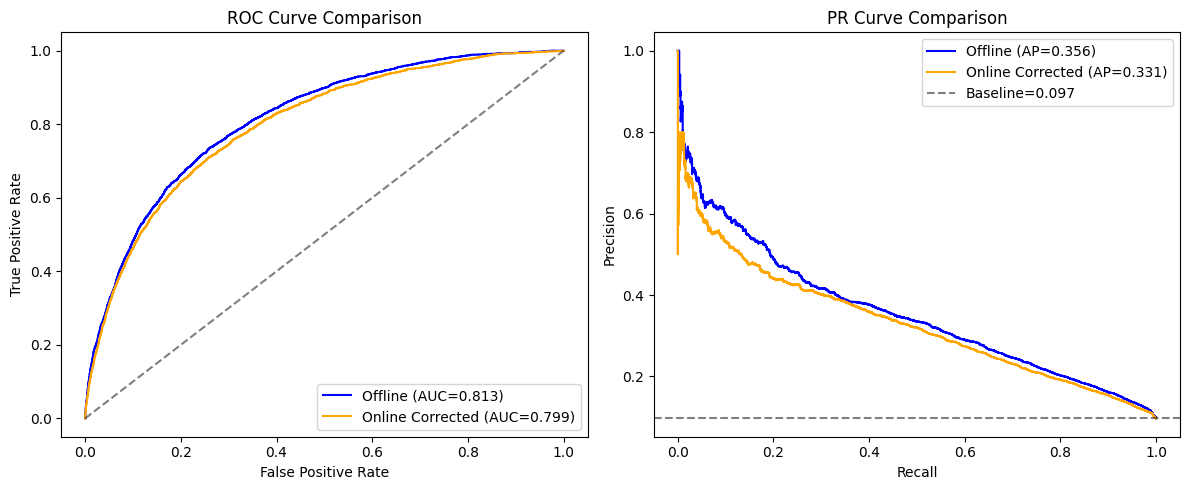

In [9]:
# === CELL 9: ROC/PR Comparison Plot ===
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

if len(np.unique(y_true)) == 2:
    for label, probs, color in [
        ("Offline", p_offline, "blue"),
        ("Online Corrected", p_final, "orange")
    ]:
        fpr, tpr, _ = roc_curve(y_true, probs)
        auc = roc_auc_score(y_true, probs)
        axes[0].plot(fpr, tpr, color=color, label=f"{label} (AUC={auc:.3f})")
else:
    axes[0].text(0.5, 0.5, "ROC undefined (single class)", ha="center", va="center")

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve Comparison")
axes[0].legend()

if 0 < y_true.sum() < len(y_true):
    for label, probs, color in [
        ("Offline", p_offline, "blue"),
        ("Online Corrected", p_final, "orange")
    ]:
        precision, recall, _ = precision_recall_curve(y_true, probs)
        ap = average_precision_score(y_true, probs)
        axes[1].plot(recall, precision, color=color, label=f"{label} (AP={ap:.3f})")
else:
    axes[1].text(0.5, 0.5, "PR undefined (single class)", ha="center", va="center")

baseline = y_true.mean()
axes[1].axhline(y=baseline, color="k", linestyle="--", alpha=0.5, label=f"Baseline={baseline:.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("PR Curve Comparison")
axes[1].legend()

plt.tight_layout()
plt.savefig(ONLINE_EVAL_PATH / "plots" / "roc_pr_comparison.png", dpi=150)
plt.show()


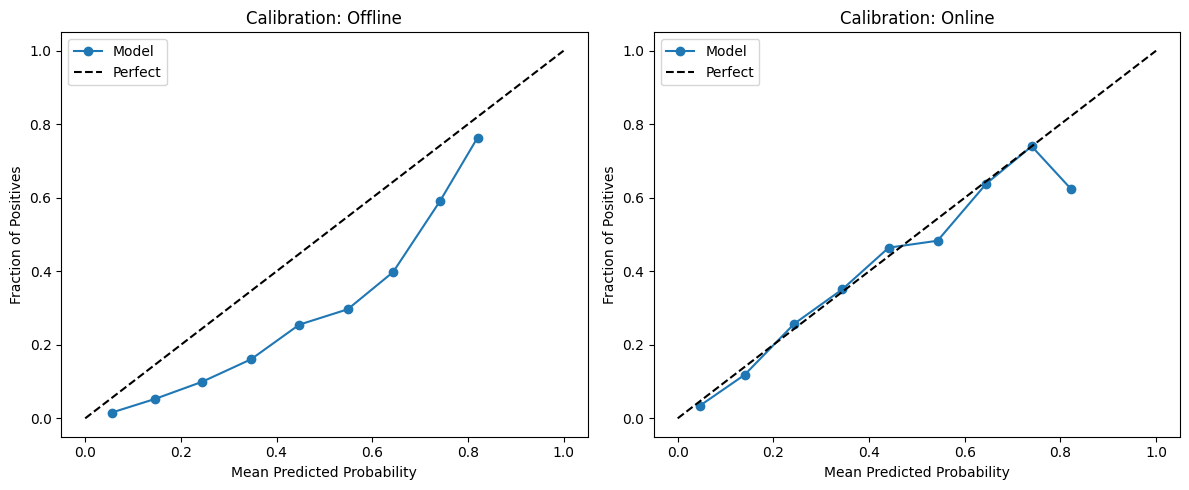

In [10]:
# === CELL 10: Calibration Comparison ===
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (label, probs) in zip(axes, [("Offline", p_offline), ("Online", p_final)]):
    if 0 < y_true.sum() < len(y_true):
        fraction_pos, mean_pred = calibration_curve(y_true, probs, n_bins=10, strategy="uniform")
        ax.plot(mean_pred, fraction_pos, "o-", label="Model")
        ax.plot([0, 1], [0, 1], "k--", label="Perfect")
        ax.set_xlabel("Mean Predicted Probability")
        ax.set_ylabel("Fraction of Positives")
        ax.set_title(f"Calibration: {label}")
        ax.legend()
    else:
        ax.text(0.5, 0.5, "Calibration undefined (single class)", ha="center", va="center")
        ax.set_title(f"Calibration: {label}")

plt.tight_layout()
plt.savefig(ONLINE_EVAL_PATH / "plots" / "calibration_comparison.png", dpi=150)
plt.show()


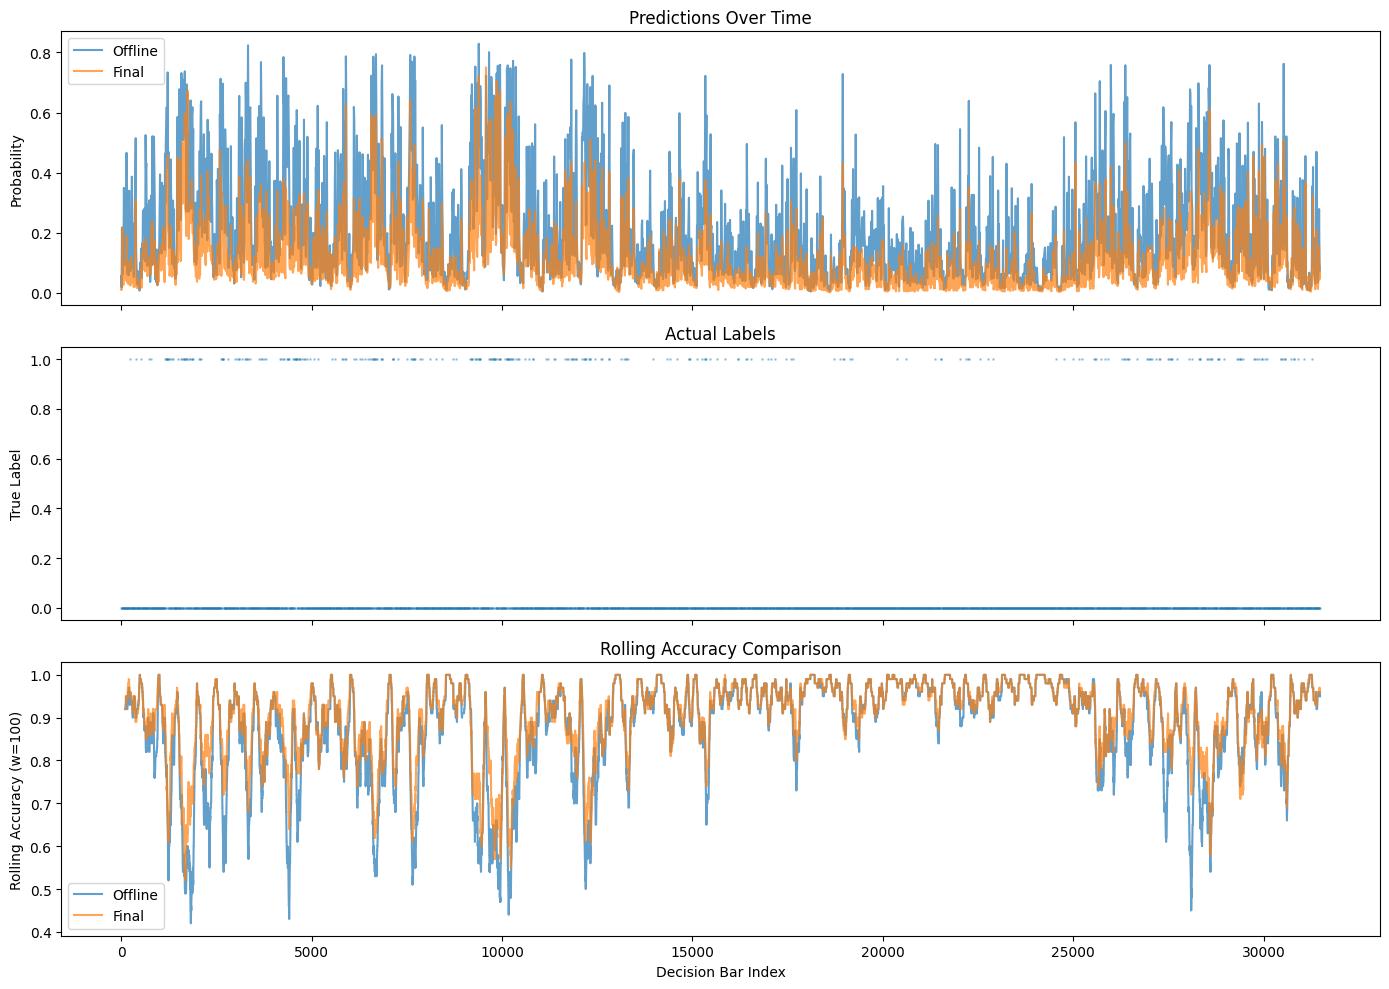

In [11]:
# === CELL 11: Time Series Plot ===
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

plot_df = results_df.iloc[::10]

axes[0].plot(plot_df["k"], plot_df["p_offline"], alpha=0.7, label="Offline")
axes[0].plot(plot_df["k"], plot_df["p_final"], alpha=0.7, label="Final")
axes[0].set_ylabel("Probability")
axes[0].set_title("Predictions Over Time")
axes[0].legend()

axes[1].scatter(plot_df["k"], plot_df["y_true"], alpha=0.3, s=1)
axes[1].set_ylabel("True Label")
axes[1].set_title("Actual Labels")

window = 100
results_df["offline_pred"] = (results_df["p_offline"] > 0.5).astype(int)
results_df["final_pred"] = (results_df["p_final"] > 0.5).astype(int)
results_df["offline_correct"] = (results_df["offline_pred"] == results_df["y_true"]).astype(int)
results_df["final_correct"] = (results_df["final_pred"] == results_df["y_true"]).astype(int)

axes[2].plot(results_df["k"], results_df["offline_correct"].rolling(window).mean(), label="Offline", alpha=0.7)
axes[2].plot(results_df["k"], results_df["final_correct"].rolling(window).mean(), label="Final", alpha=0.7)
axes[2].set_xlabel("Decision Bar Index")
axes[2].set_ylabel(f"Rolling Accuracy (w={window})")
axes[2].set_title("Rolling Accuracy Comparison")
axes[2].legend()

plt.tight_layout()
plt.savefig(ONLINE_EVAL_PATH / "plots" / "time_series.png", dpi=150)
plt.show()


In [12]:
# === CELL 12: Save Results ===
with open(ONLINE_EVAL_PATH / "metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

results_df.to_parquet(ONLINE_EVAL_PATH / "predictions.parquet", index=False)
periodic_df.to_csv(ONLINE_EVAL_PATH / "periodic_metrics.csv", index=False)

print(f"Results saved to: {ONLINE_EVAL_PATH}")


Results saved to: C:\Users\vitil\OneDrive\Desktop\online_barrier_classifier\artifacts\online_eval
